In [ ]:
import cv2
import numpy as np
import glob

# Definir dimensiones del tablero (esquinas internas)
chessboard_size = (9, 6)

# Criterio de terminación de subpixeles
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)

# Preparar puntos 3D (0,0,0 ... 8,5,0)
objp = np.zeros((np.prod(chessboard_size), 3), np.float32)
objp[:, :2] = np.mgrid[0:chessboard_size[0], 0:chessboard_size[1]].T.reshape(-1, 2)

objpoints = [] # Puntos 3D
imgpoints = [] # Puntos 2D

# Cargar imágenes del tablero
images = glob.glob('chessboard3/*.jpg')




In [ ]:
for fname in images:
    img = cv2.imread(fname)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    ret, corners = cv2.findChessboardCorners(gray, chessboard_size, None)
    if ret:
        objpoints.append(objp)
        corners2 = cv2.cornerSubPix(gray, corners, (11, 11), (-1, -1), criteria)
        imgpoints.append(corners2)



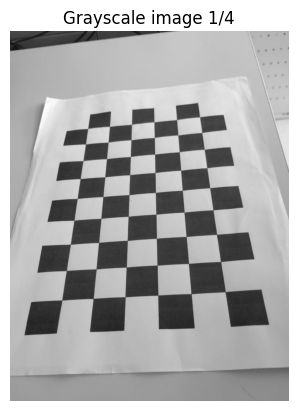

Corners detected and image saved as /calibrated_result_gray1.jpg


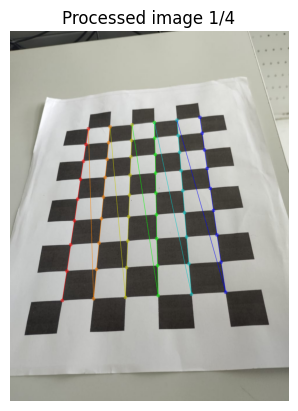

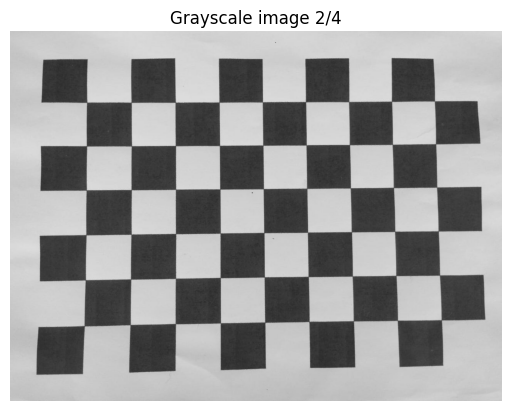

Corners detected and image saved as /calibrated_result_gray2.jpg


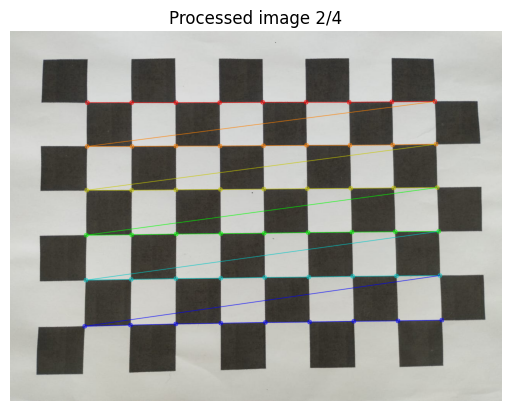

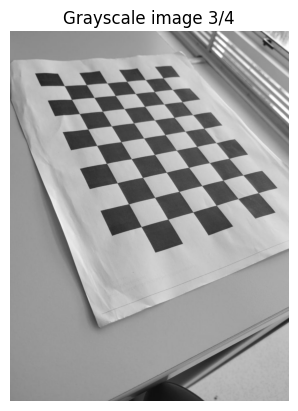

Corners detected and image saved as /calibrated_result_gray3.jpg


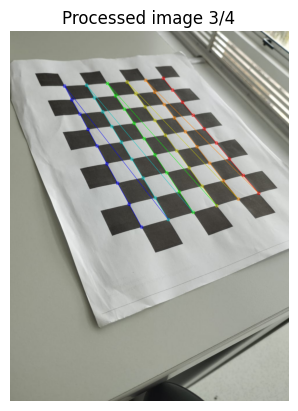

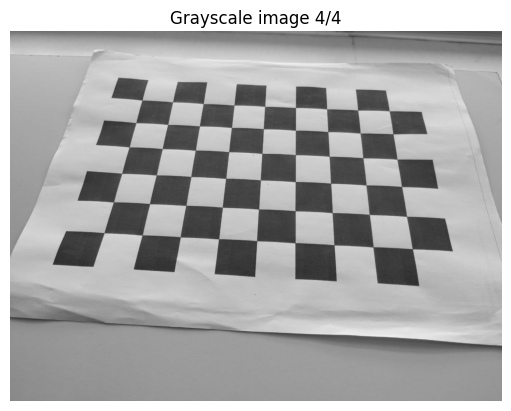

Corners detected and image saved as /calibrated_result_gray4.jpg


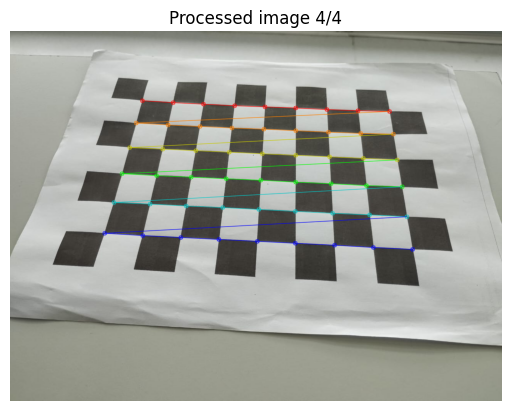

In [ ]:
import cv2
import matplotlib.pyplot as plt

# Loop through the images and process each one
for i, fname in enumerate(images):
    # Read the original image
    img = cv2.imread(fname)

    # Convert the image to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Show the grayscale image using matplotlib
    gray_rgb = cv2.cvtColor(gray, cv2.COLOR_GRAY2RGB)  # Convert grayscale to RGB for displaying
    plt.imshow(gray_rgb)
    plt.title(f'Grayscale image {i+1}/{len(images)}')
    plt.axis('off')  # Hide axes for better visualization
    plt.show()

    # Try to find the chessboard corners
    ret, corners = cv2.findChessboardCorners(gray, chessboard_size, None)

    if ret:
        objpoints.append(objp)
        corners2 = cv2.cornerSubPix(gray, corners, (11, 11), (-1, -1), criteria)
        imgpoints.append(corners2)

        # Draw the detected corners on the image
        img_with_corners = cv2.drawChessboardCorners(img, chessboard_size, corners2, ret)

        # Save the updated image with corners
        output_filename = f'/calibrated_result_gray{i+1}.jpg'  # Save to Google Drive

        print(f'Corners detected and image saved as {output_filename}')
    else:
        # If no corners are found, just save the original image
        output_filename = f'/calibrated_result_gray{i+1}'  # Save to Google Drive

        print(f'No corners detected')

    # Show the current image with detected corners (if any) using matplotlib
    img_rgb = cv2.cvtColor(img_with_corners if ret else img, cv2.COLOR_BGR2RGB)
    plt.imshow(img_rgb)
    plt.title(f'Processed image {i+1}/{len(images)}')
    plt.axis('off')  # Hide axes for better visualization
    plt.show()

    # Optional: Wait a bit before continuing to the next image (usually for notebook interactivity)
    plt.pause(0.1)  # Pause for 0.1 seconds to allow the image to render


In [ ]:
# Calibración
ret, mtx, dist, rvecs, tvecs = cv2.calibrateCamera(objpoints, imgpoints, gray.shape[::-1], None, None)

print("Matriz de la cámara:\n", mtx)
print("Coeficientes de distorsión:\n", dist)


Matriz de la cámara:
 [[1.42891870e+03 0.00000000e+00 6.11032993e+02]
 [0.00000000e+00 1.42675429e+03 2.78440683e+02]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]
Coeficientes de distorsión:
 [[-5.87067757e-04  4.79467186e-02 -6.40612828e-03  7.28867324e-03
  -7.93171946e-01]]


In [ ]:

# Corrección de una imagen de prueba
img = cv2.imread(images[1])
h, w = img.shape[:2]
newcameramtx, roi = cv2.getOptimalNewCameraMatrix(mtx, dist, (w,h), 1, (w,h))

dst = cv2.undistort(img, mtx, dist, None, newcameramtx)
cv2.imwrite('calibrated_result.jpg', dst)

True

Corners detected and undistorted image saved as /calibrated_result_gray4_undistorted.jpg


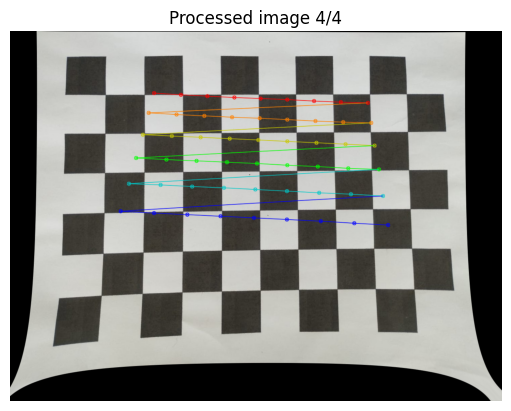

In [ ]:
# After the corners are detected and img_with_corners is generated
if ret:
    objpoints.append(objp)
    corners2 = cv2.cornerSubPix(gray, corners, (11, 11), (-1, -1), criteria)
    imgpoints.append(corners2)

    # Draw the detected corners on the image
    # Ensure 'ret' is passed as a boolean
    img_with_corners = cv2.drawChessboardCorners(img, chessboard_size, corners2, bool(ret))

    # Undistort the image with corners
    img_with_corners_undistorted = cv2.undistort(img_with_corners, mtx, dist, None, newcameramtx)

    # Save the updated, undistorted image with corners
    output_filename = f'/calibrated_result_gray{i+1}_undistorted.jpg'  # Save to Google Drive
    cv2.imwrite(output_filename, img_with_corners_undistorted)

    print(f'Corners detected and undistorted image saved as {output_filename}')
else:
    # If no corners are found, just save the original image (no undistortion)
    output_filename = f'/calibrated_result_gray{i+1}_no_corners.jpg'  # Save to Google Drive
    cv2.imwrite(output_filename, img)

    print(f'No corners detected, image saved as {output_filename}')

# Show the current image with detected corners (undistorted if applicable) using matplotlib
img_rgb = cv2.cvtColor(img_with_corners_undistorted if ret else img, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)
plt.title(f'Processed image {i+1}/{len(images)}')
plt.axis('off')  # Hide axes for better visualization
plt.show()


Matriz de la cámara:

 [[392.6854445    0.         377.99620789]

 [  0.         383.74100506 489.10565681]

 [  0.           0.           1.        ]]

Coeficientes de distorsión:
 [[ 0.01187246  0.00663635 -0.00337861  0.0020808  -0.01034995]]

Matriz de la cámara:

 [[751.79724011   0.         427.38143961]

 [  0.         753.21474153 373.86987092]

 [  0.           0.           1.        ]]

Coeficientes de distorsión:
 [[-0.16333898  0.21145271 -0.01714256  0.00495147 -0.00064214]]

Matriz de la cámara:

 [[1.42891870e+03 0.00000000e+00 6.11032993e+02]

 [0.00000000e+00 1.42675429e+03 2.78440683e+02]

 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]

Coeficientes de distorsión:

 [[-5.87067757e-04  4.79467186e-02 -6.40612828e-03  7.28867324e-03
  -7.93171946e-01]]